# ISCAS/TCAS2 2026 - Notebook 5

## Noisy oracles vs noisy circuits

This notebook adds a focused experiment for the discussion on **noisy oracles** and **non-isolated quantum channels**. The goal is to separate three regimes:

1. **Isolated ideal oracle**: clean Grover-walk baseline.
2. **Isolated oracle under circuit noise**: same oracle, but depolarizing/readout errors in the implementation.
3. **Noisy / non-isolated oracle**: the oracle call itself is modified, either by stochastic marking errors or by a coherent leakage channel coupled to an environment register.

## Setup


In [7]:
#!git clone https://github.com/leonardoLavagna/Iscas2026

In [4]:
import os
os.chdir("Iscas2026")


In [8]:
#!pip install -r requirements.txt

In [9]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.result import marginal_counts
from qiskit_aer import AerSimulator

from utilities.grover_walk import (
    grover_diffusion_gate,
    phase_oracle_on_register,
    flipflop_shift_swap,
    coined_grover_walk_search,
)
from utilities.noise_level_and_topology import (
    make_backend_with_noise,
    sweep_success,
    first_two_peaks,
    estimate_kappa,
)


## Experimental constants

The default setting keeps the experiment small enough for a laptop while preserving the Grover-walk shape.

- `n_key_qubits = 5`, so the search space has size `N = 32`.
- `marked_key = 5`, corresponding to a fixed marked bitstring.
- `steps_range` sweeps the number of Grover-walk steps.


In [10]:
SEED = 2026
rng = random.Random(SEED)
np.random.seed(SEED)

n_key_qubits = 5
N = 2 ** n_key_qubits
marked_key = 5
marked_bits = format(marked_key, f"0{n_key_qubits}b")

steps_range = list(range(0, 26))
shots = 2048
trajectories = 32

print("N =", N)
print("marked key =", marked_key)
print("marked bits =", marked_bits)


N = 32
marked key = 5
marked bits = 00101


## Baseline 1: isolated ideal oracle

This is the clean Grover-walk baseline from `utilities.grover_walk`.


In [11]:
ideal_backend = AerSimulator()

ideal_curve = sweep_success(
    marked_key=marked_key,
    steps_list=steps_range,
    shots=shots,
    backend=ideal_backend,
)


## Baseline 2: isolated oracle with implementation noise

This keeps the **same isolated oracle**, but runs the circuit on a depolarizing/readout noisy backend using `utilities.noise_level_and_topology.make_backend_with_noise`.

This is ordinary circuit noise: the oracle model is not changed, but its physical implementation is imperfect.


In [12]:
noisy_backend = make_backend_with_noise(
    n_qubits=2 * n_key_qubits,
    p1=1e-3,
    p2=5e-3,
    p_meas=2e-2,
)

circuit_noise_curve = sweep_success(
    marked_key=marked_key,
    steps_list=steps_range,
    shots=shots,
    backend=noisy_backend,
)


## Helper functions for noisy-oracle experiments

The next functions build Grover-walk circuits in which the oracle itself is modified.

Two variants are implemented:

1. **Stochastic marking noise**: at each query, the oracle marks the correct state with probability `1 - eta`, otherwise it marks a wrong state.
2. **Leaky-channel oracle**: after the correct phase oracle, a one-qubit environment stores a function of the position register. The final success probability ignores this environment, so the observed dynamics is the reduced channel obtained by tracing it out.


In [13]:
def random_wrong_bitstring(n: int, true_bits: str, rng: random.Random) -> str:
    """Sample a wrong marked bitstring of length n."""
    assert len(true_bits) == n
    candidates = [format(x, f"0{n}b") for x in range(2**n) if format(x, f"0{n}b") != true_bits]
    return rng.choice(candidates)


def noisy_oracle_schedule(n: int, true_bits: str, steps: int, eta: float, rng: random.Random):
    """
    Build a per-step oracle schedule.

    With probability 1-eta, use the true marked state.
    With probability eta, use a wrong marked state.
    """
    schedule = []
    for _ in range(steps):
        if rng.random() < eta:
            schedule.append(random_wrong_bitstring(n, true_bits, rng))
        else:
            schedule.append(true_bits)
    return schedule


def apply_leakage(qc: QuantumCircuit, *, pos_start: int, n: int, env_index: int, mode: str):
    """
    Coherently copy a simple function h(x) of the position register into env.

    The environment is kept until the end and is not part of the success measurement.
    This implements a minimal non-isolated channel dilation.
    """
    if mode is None:
        return
    if mode == "msb":
        qc.cx(pos_start + n - 1, env_index)
    elif mode == "lsb":
        qc.cx(pos_start, env_index)
    elif mode == "parity":
        for i in range(n):
            qc.cx(pos_start + i, env_index)
    else:
        raise ValueError(f"Unsupported leakage mode: {mode}")


def custom_grover_walk_circuit(
    n: int,
    marked_state: str,
    steps: int,
    *,
    oracle_schedule=None,
    leakage_mode=None,
    measure: bool = True,
):
    """
    Build a Grover-walk circuit using repository primitives, with optional noisy/non-isolated oracle behavior.

    If oracle_schedule is provided, it must contain one marked bitstring per step.
    If leakage_mode is not None, one environment qubit is appended and coupled after each oracle call.
    """
    if oracle_schedule is None:
        oracle_schedule = [marked_state] * steps
    if len(oracle_schedule) != steps:
        raise ValueError("oracle_schedule length must equal steps")

    base_total = 2 * n
    has_env = leakage_mode is not None
    n_total = base_total + (1 if has_env else 0)
    coin_start = 0
    pos_start = n
    env_index = base_total if has_env else None

    qc = QuantumCircuit(n_total, n_total if measure else 0)

    # Initialize coin and position registers in the uniform state.
    qc.h(range(base_total))

    diffusion = grover_diffusion_gate(n)
    shift = flipflop_shift_swap(n, coin_start, pos_start)

    for step_marked_state in oracle_schedule:
        oracle = phase_oracle_on_register(n_total, pos_start, n, step_marked_state)
        qc.append(oracle, range(n_total))

        if has_env:
            apply_leakage(qc, pos_start=pos_start, n=n, env_index=env_index, mode=leakage_mode)

        qc.append(diffusion, range(coin_start, coin_start + n))
        qc.append(shift, range(base_total))

    if measure:
        qc.measure(range(n_total), range(n_total))

    return qc


def position_success_probability(qc: QuantumCircuit, marked_state: str, backend, shots: int, n: int) -> float:
    """Run a circuit and return the success probability on the position register."""
    tqc = transpile(qc, backend, optimization_level=2)
    result = backend.run(tqc, shots=shots).result()
    pos_counts = marginal_counts(result, indices=list(range(n, 2 * n))).get_counts()
    return pos_counts.get(marked_state, 0) / shots


def stochastic_noisy_oracle_success(
    *,
    n: int,
    marked_state: str,
    steps: int,
    eta: float,
    backend,
    shots: int,
    trajectories: int,
    seed: int,
):
    """
    Estimate success probability for a stochastic noisy oracle by averaging trajectories.

    Each trajectory samples a different sequence of correct/wrong markers across oracle calls.
    """
    local_rng = random.Random(seed + 1009 * steps + int(1e6 * eta))
    shots_per_traj = max(1, shots // trajectories)
    weighted_success = 0.0
    total_shots = 0

    for _ in range(trajectories):
        schedule = noisy_oracle_schedule(n, marked_state, steps, eta, local_rng)
        qc = custom_grover_walk_circuit(
            n=n,
            marked_state=marked_state,
            steps=steps,
            oracle_schedule=schedule,
            leakage_mode=None,
            measure=True,
        )
        p_succ = position_success_probability(qc, marked_state, backend, shots_per_traj, n)
        weighted_success += p_succ * shots_per_traj
        total_shots += shots_per_traj

    return weighted_success / total_shots


def leaky_oracle_success(
    *,
    n: int,
    marked_state: str,
    steps: int,
    leakage_mode: str,
    backend,
    shots: int,
):
    """Success probability for the non-isolated oracle with a one-qubit environment."""
    qc = custom_grover_walk_circuit(
        n=n,
        marked_state=marked_state,
        steps=steps,
        oracle_schedule=None,
        leakage_mode=leakage_mode,
        measure=True,
    )
    return position_success_probability(qc, marked_state, backend, shots, n)


## Experiment 3a: stochastic noisy oracle

Here the oracle itself is unstable. At each query it marks the correct state with probability `1 - eta`, and a wrong state with probability `eta`.

This is different from circuit noise: the black-box predicate is no longer a fixed isolated oracle.


In [14]:
etas = [0.01, 0.05, 0.10]

stochastic_oracle_curves = {}
for eta in etas:
    ys = []
    for steps in steps_range:
        ys.append(
            stochastic_noisy_oracle_success(
                n=n_key_qubits,
                marked_state=marked_bits,
                steps=steps,
                eta=eta,
                backend=ideal_backend,
                shots=shots,
                trajectories=trajectories,
                seed=SEED,
            )
        )
    stochastic_oracle_curves[eta] = np.array(ys)
    print(f"eta={eta}: max success={np.max(stochastic_oracle_curves[eta]):.3f}")


eta=0.01: max success=1.000
eta=0.05: max success=0.925
eta=0.1: max success=0.810


## Experiment 3b: leaky non-isolated oracle

This oracle is still correctly marked, but each oracle call is followed by a coherent coupling to a one-qubit environment.

For example, with `leakage_mode="parity"`, the channel stores the parity of the position register in the environment. The environment is ignored in the final measurement, so the observed map is a reduced channel.


In [15]:
leakage_modes = ["msb", "parity"]

leaky_oracle_curves = {}
for mode in leakage_modes:
    ys = []
    for steps in steps_range:
        ys.append(
            leaky_oracle_success(
                n=n_key_qubits,
                marked_state=marked_bits,
                steps=steps,
                leakage_mode=mode,
                backend=ideal_backend,
                shots=shots,
            )
        )
    leaky_oracle_curves[mode] = np.array(ys)
    print(f"leakage={mode}: max success={np.max(leaky_oracle_curves[mode]):.3f}")


leakage=msb: max success=0.523
leakage=parity: max success=0.528


## Summary table

We compare peak success probability, optimal step, and peak-based damping estimate.


In [16]:
def summarize_curve(label: str, xs, ys):
    xs = np.array(xs)
    ys = np.array(ys)
    peaks = first_two_peaks(xs, ys)
    return {
        "label": label,
        "k_opt": int(xs[np.argmax(ys)]),
        "p_opt": float(np.max(ys)),
        "first_peak": peaks[0] if len(peaks) >= 1 else None,
        "second_peak": peaks[1] if len(peaks) >= 2 else None,
        "kappa": float(estimate_kappa(peaks)) if len(peaks) >= 2 else np.nan,
    }

rows = [
    summarize_curve("ideal isolated oracle", steps_range, ideal_curve),
    summarize_curve("isolated oracle + circuit noise", steps_range, circuit_noise_curve),
]

for eta, curve in stochastic_oracle_curves.items():
    rows.append(summarize_curve(f"stochastic noisy oracle eta={eta}", steps_range, curve))

for mode, curve in leaky_oracle_curves.items():
    rows.append(summarize_curve(f"leaky oracle h={mode}", steps_range, curve))

summary = pd.DataFrame(rows)
summary


,label,k_opt,p_opt,first_peak,second_peak,kappa
0,ideal isolated oracle,8,0.999023,"(2, 0.259765625)","(4, 0.59423828125)",NaN
1,isolated oracle + circuit noise,6,0.250977,"(2, 0.15283203125)","(4, 0.24609375)",NaN
2,stochastic noisy oracle eta=0.01,8,1.000000,"(2, 0.28125)","(4, 0.6025390625)",NaN
3,stochastic noisy oracle eta=0.05,9,0.924805,"(2, 0.25390625)","(6, 0.89453125)",NaN
4,stochastic noisy oracle eta=0.1,8,0.809570,"(4, 0.56982421875)","(8, 0.8095703125)",NaN
5,leaky oracle h=msb,8,0.523438,"(4, 0.3232421875)","(8, 0.5234375)",NaN
6,leaky oracle h=parity,9,0.527832,"(4, 0.314453125)","(9, 0.52783203125)",NaN


## Plot

The ideal isolated curve gives the reference amplification dynamics. Circuit noise should mostly damp the peaks. Noisy/non-isolated oracle variants modify the oracle interaction itself, so their behavior should not be interpreted as merely a lower-quality implementation of the same oracle.


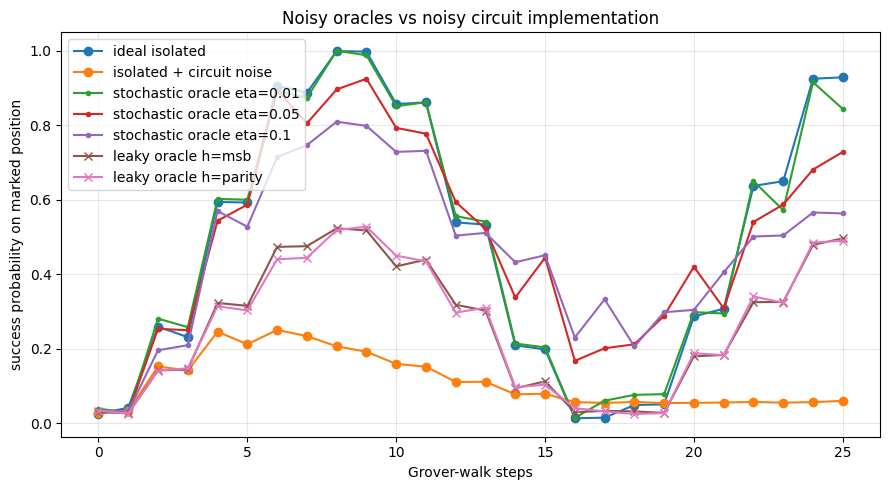

In [17]:
plt.figure(figsize=(9, 5))
plt.plot(steps_range, ideal_curve, marker="o", label="ideal isolated")
plt.plot(steps_range, circuit_noise_curve, marker="o", label="isolated + circuit noise")

for eta, curve in stochastic_oracle_curves.items():
    plt.plot(steps_range, curve, marker=".", label=f"stochastic oracle eta={eta}")

for mode, curve in leaky_oracle_curves.items():
    plt.plot(steps_range, curve, marker="x", label=f"leaky oracle h={mode}")

plt.xlabel("Grover-walk steps")
plt.ylabel("success probability on marked position")
plt.title("Noisy oracles vs noisy circuit implementation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_noisy_oracles_success.png", dpi=200)
plt.show()
